# LeNet

In [152]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

In [153]:
# 展示高清图
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')

In [154]:
# 超参数
seed = 1145
batch_size = 256
epochs = 20
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
learning_rate = 0.9

In [155]:
torch.manual_seed(seed)

In [156]:
# 制作数据集

# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.1307, 0.3081)
])

train_dataset = datasets.MNIST(root='./datasets/mnist', 
                               train=True, 
                               download=True, 
                               transform=transform)
test_dataset = datasets.MNIST(root='./datasets/mnist', 
                              train=False, 
                              download=True, 
                              transform=transform)

In [157]:
# 批次加载器
train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=batch_size, 
                          shuffle=True)     # 打乱数据
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)

In [158]:
# 定义网络
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5,padding=2),nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16,120, kernel_size=5),nn.Tanh(),
            nn.Flatten(),                                    # 展平
            nn.Linear(120,84),nn.Tanh(),
            nn.Linear(84,10)
        )
    def forward(self,x):
        x = self.net(x)
        return x

In [159]:
# 查看网络结构
X = torch.rand(size=(1, 1, 28, 28))     # 随机生成测试图
for layer in LeNet().net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Tanh output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Tanh output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Conv2d output shape: 	 torch.Size([1, 120, 1, 1])
Tanh output shape: 	 torch.Size([1, 120, 1, 1])
Flatten output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Tanh output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [160]:
model = LeNet().to(device)

In [161]:
# 损失函数
loss_fn = nn.CrossEntropyLoss()

In [162]:
# 优化算法
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

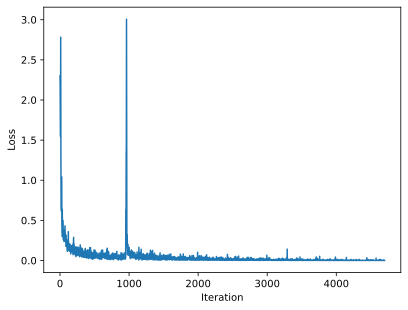

In [163]:
# 训练网络
losses = []
for epoch in range(epochs):
    for (x,y) in train_loader:
        x,y = x.to(device),y.to(device)
        Pred = model(x)
        loss = loss_fn(Pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

fig, ax = plt.subplots()
ax.plot(range(len(losses)), losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
plt.show()

In [164]:
# 测试网络
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images,labels = images.to(device),labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)       # 索引/预测结果
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network: %.4f %%' % (
    100 * correct / total))

Accuracy of the network: 98.8100 %
